<a href="https://colab.research.google.com/github/LinaMariaCastro/curso-ia-para-economia/blob/main/clases/3_Analisis_y_visualizacion_datos/6_EDA.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# **Inteligencia Artificial con Aplicaciones en Economía I**

- 👩‍🏫 **Profesora:** [Lina María Castro](https://www.linkedin.com/in/lina-maria-castro)  
- 📧 **Email:** [lmcastroco@gmail.com](mailto:lmcastroco@gmail.com)  
- 🎓 **Universidad:** Universidad Externado de Colombia - Facultad de Economía

# 🔎📊**Análisis Exploratorio de Datos (Exploratory Data Analysis - EDA)**

👉 Con datos listos, podemos descubrir patrones.

✅ Resultado: entendemos la historia detrás de los datos y generamos hipótesis.

**Objetivos de Aprendizaje:**

Al finalizar este notebook, serás capaz de:

1. **Diagnosticar un conjunto de datos:** Utilizar funciones de Pandas para obtener un resumen estadístico y estructural de los datos, identificando tipos de variables, valores nulos y dimensiones.

2. **Analizar y visualizar distribuciones:** Crear e interpretar gráficos univariados (histogramas, boxplots) para entender la distribución, tendencia central y dispersión de las variables económicas.

3. **Descubrir relaciones entre variables:** Implementar y analizar gráficos multivariados (scatter plots, heatmaps) para identificar correlaciones, covarianzas y patrones entre múltiples indicadores económicos.

**Introducción**

Imaginemos que la OCDE nos contrata para entender los factores que determinan el desarrollo económico de los países. Antes de lanzarnos a construir un complejo modelo econométrico con regresiones y series de tiempo, un buen economista haría un "trabajo de campo": viajaría (conceptualmente) a varios países, observaría sus economías, hablaría con la gente y recolectaría datos preliminares.

El Análisis Exploratorio de Datos (EDA) es precisamente eso, es el proceso de usar estadísticas descriptivas y visualizaciones para "dialogar" con nuestros datos.

Queremos que los datos nos cuenten su historia:

- ¿Cómo es un país "promedio" en nuestra muestra? (Media, mediana)

- ¿Qué tan desigual es el mundo en términos de ingreso o salud? (Desviación estándar, percentiles, boxplots)

- ¿Existen "clubes de convergencia" o grupos de países con características similares? (Análisis de categorías, gráficos de densidad)

- ¿Parece haber una relación entre la inversión en educación y el crecimiento del PIB? (Gráficos de dispersión, correlación)

Hacer un buen EDA nos permite formular mejores hipótesis, detectar problemas de calidad en los datos (como outliers o valores faltantes) y construir modelos más robustos y significativos. Es el arte de hacer las preguntas correctas a nuestros datos antes de pedirles que nos den respuestas definitivas.

## Importar librerías

In [ ]:
# En VS Code, si no has instalado las librerías, ejecutar:
# %pip install matplotlib
# %pip install seaborn
# %pip install plotly

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px
import warnings
warnings.filterwarnings('ignore')

## Mejorar visualización de los dataframes y los gráficos

In [2]:
# Que muestre todas las columnas
pd.options.display.max_columns = None
# En los dataframes, mostrar los float con dos decimales
pd.options.display.float_format = '{:,.2f}'.format

In [3]:
# Configuraciones para una mejor visualización de los gráficos
sns.set_style("whitegrid")

## Cargar el dataset

Usaremos un dataset de **Gapminder** (https://www.gapminder.org/) que viene precargado en Plotly Express para facilitar el acceso. Contiene datos de PIB per cápita PPA a precios constantes, esperanza de vida y población para varios países a lo largo del tiempo.

**Nota**

Gapminder es una fundación educativa independiente y sin fines de lucro. Fue cofundada en Suecia por el legendario médico y estadístico Hans Rosling, junto a su hijo y su nuera.

La misión de la Fundación Gapminder es luchar contra las ideas erróneas y preconcebidas sobre el desarrollo global. Rosling sostenía que la mayoría de la gente, incluso personas muy educadas y en posiciones de poder, tienen una visión del mundo anticuada, dividiendo a los países en "desarrollados" y "en vías de desarrollo", una dicotomía que los datos ya no respaldan.

El método de Gapminder para combatir esta desinformación es el uso magistral de la visualización de datos para contar historias (data storytelling).

In [4]:
df = px.data.gapminder()

## Exploración inicial del dataset

In [5]:
df

,country,continent,year,lifeExp,pop,gdpPercap,iso_alpha,iso_num
0,Afghanistan,Asia,1952,28.80,8425333,779.45,AFG,4
1,Afghanistan,Asia,1957,30.33,9240934,820.85,AFG,4
2,Afghanistan,Asia,1962,32.00,10267083,853.10,AFG,4
3,Afghanistan,Asia,1967,34.02,11537966,836.20,AFG,4
4,Afghanistan,Asia,1972,36.09,13079460,739.98,AFG,4
...,...,...,...,...,...,...,...,...
1699,Zimbabwe,Africa,1987,62.35,9216418,706.16,ZWE,716
1700,Zimbabwe,Africa,1992,60.38,10704340,693.42,ZWE,716
1701,Zimbabwe,Africa,1997,46.81,11404948,792.45,ZWE,716
1702,Zimbabwe,Africa,2002,39.99,11926563,672.04,ZWE,716


In [6]:
df.shape

(1704, 8)

In [7]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1704 entries, 0 to 1703
Data columns (total 8 columns):
 #   Column     Non-Null Count  Dtype  
---  ------     --------------  -----  
 0   country    1704 non-null   object 
 1   continent  1704 non-null   object 
 2   year       1704 non-null   int64  
 3   lifeExp    1704 non-null   float64
 4   pop        1704 non-null   int64  
 5   gdpPercap  1704 non-null   float64
 6   iso_alpha  1704 non-null   object 
 7   iso_num    1704 non-null   int64  
dtypes: float64(2), int64(3), object(3)
memory usage: 106.6+ KB


**Interpretación de los resultados:**

In [8]:
# vamos a renombrar las columnas para un mejor entendimiento
df.rename(columns={'lifeExp':'esperanza_vida',
                   'pop':'poblacion',
                   'gdpPercap':'pib_per_capita',
                   'country':'pais',
                   'continent':'continente',
                   'year':'año'},
          inplace=True)
df

,pais,continente,año,esperanza_vida,poblacion,pib_per_capita,iso_alpha,iso_num
0,Afghanistan,Asia,1952,28.80,8425333,779.45,AFG,4
1,Afghanistan,Asia,1957,30.33,9240934,820.85,AFG,4
2,Afghanistan,Asia,1962,32.00,10267083,853.10,AFG,4
3,Afghanistan,Asia,1967,34.02,11537966,836.20,AFG,4
4,Afghanistan,Asia,1972,36.09,13079460,739.98,AFG,4
...,...,...,...,...,...,...,...,...
1699,Zimbabwe,Africa,1987,62.35,9216418,706.16,ZWE,716
1700,Zimbabwe,Africa,1992,60.38,10704340,693.42,ZWE,716
1701,Zimbabwe,Africa,1997,46.81,11404948,792.45,ZWE,716
1702,Zimbabwe,Africa,2002,39.99,11926563,672.04,ZWE,716


In [9]:
df['año'] = df['año'].astype('str')

In [10]:
df.drop(columns=['iso_alpha', 'iso_num'], inplace=True)

In [11]:
df.head()

,pais,continente,año,esperanza_vida,poblacion,pib_per_capita
0,Afghanistan,Asia,1952,28.80,8425333,779.45
1,Afghanistan,Asia,1957,30.33,9240934,820.85
2,Afghanistan,Asia,1962,32.00,10267083,853.10
3,Afghanistan,Asia,1967,34.02,11537966,836.20
4,Afghanistan,Asia,1972,36.09,13079460,739.98


## Análisis de variables no numéricas

### Variables categóricas

Para las variables categóricas, nos interesa saber cuántas categorías únicas existen, cuáles son y cómo se distribuyen las observaciones entre ellas.

In [12]:
df['continente'].unique()

array(['Asia', 'Europe', 'Africa', 'Americas', 'Oceania'], dtype=object)

In [13]:
df['continente'].nunique()

5

In [14]:
print("Conteo de observaciones por continente:")
print(df['continente'].value_counts())

Conteo de observaciones por continente:
continente
Africa      624
Asia        396
Europe      360
Americas    300
Oceania      24
Name: count, dtype: int64


In [15]:
print("\nPorcentaje de observaciones por continente:")
print(df['continente'].value_counts(normalize=True) * 100)


Porcentaje de observaciones por continente:
continente
Africa     36.62
Asia       23.24
Europe     21.13
Americas   17.61
Oceania     1.41
Name: proportion, dtype: float64


Asia y África son los continentes con más observaciones en nuestra muestra, lo que tiene sentido ya que tienen un gran número de países. Oceanía tiene la menor cantidad.

### Análisis de los individuos objeto de estudio

¿Qué países se encuentran en la base de datos?

In [16]:
df['pais'].unique()

array(['Afghanistan', 'Albania', 'Algeria', 'Angola', 'Argentina',
       'Australia', 'Austria', 'Bahrain', 'Bangladesh', 'Belgium',
       'Benin', 'Bolivia', 'Bosnia and Herzegovina', 'Botswana', 'Brazil',
       'Bulgaria', 'Burkina Faso', 'Burundi', 'Cambodia', 'Cameroon',
       'Canada', 'Central African Republic', 'Chad', 'Chile', 'China',
       'Colombia', 'Comoros', 'Congo, Dem. Rep.', 'Congo, Rep.',
       'Costa Rica', "Cote d'Ivoire", 'Croatia', 'Cuba', 'Czech Republic',
       'Denmark', 'Djibouti', 'Dominican Republic', 'Ecuador', 'Egypt',
       'El Salvador', 'Equatorial Guinea', 'Eritrea', 'Ethiopia',
       'Finland', 'France', 'Gabon', 'Gambia', 'Germany', 'Ghana',
       'Greece', 'Guatemala', 'Guinea', 'Guinea-Bissau', 'Haiti',
       'Honduras', 'Hong Kong, China', 'Hungary', 'Iceland', 'India',
       'Indonesia', 'Iran', 'Iraq', 'Ireland', 'Israel', 'Italy',
       'Jamaica', 'Japan', 'Jordan', 'Kenya', 'Korea, Dem. Rep.',
       'Korea, Rep.', 'Kuwait', 'Leba

¿Cuántos países son?

In [17]:
df['pais'].nunique()

142

In [18]:
df['pais'].value_counts()

,count
pais,
Afghanistan,12
Albania,12
Algeria,12
Angola,12
Argentina,12
...,...
Vietnam,12
West Bank and Gaza,12
"Yemen, Rep.",12


### Análisis de la dimensión temporal

¿Qué años se encuentran en la base de datos?

In [19]:
df['año'].unique()

array(['1952', '1957', '1962', '1967', '1972', '1977', '1982', '1987',
       '1992', '1997', '2002', '2007'], dtype=object)

¿Cuántos años son?

In [20]:
df['año'].nunique()

12

In [21]:
df['año'].value_counts()

,count
año,
1952,142
1957,142
1962,142
1967,142
1972,142
1977,142
1982,142
1987,142
1992,142


## Estadísticas Descriptivas (Análisis Univariado)

Ahora, vamos a calcular las estadísticas fundamentales para nuestras variables numéricas.

In [22]:
print("Estadísticas Descriptivas de las Variables Numéricas:")
df.describe()

Estadísticas Descriptivas de las Variables Numéricas:


,esperanza_vida,poblacion,pib_per_capita
count,"1,704.00","1,704.00","1,704.00"
mean,59.47,"29,601,212.32","7,215.33"
std,12.92,"106,157,896.74","9,857.45"
min,23.60,"60,011.00",241.17
25%,48.20,"2,793,664.00","1,202.06"
50%,60.71,"7,023,595.50","3,531.85"
75%,70.85,"19,585,221.75","9,325.46"
max,82.60,"1,318,683,096.00","113,523.13"


**Trabajo en parejas**

Realicen y compartan con la clase un análisis de estas estadísticas para esperanza de vida, población y PIB per cápita. Tiempo: 2 minutos.

In [23]:
df.describe()

,esperanza_vida,poblacion,pib_per_capita
count,"1,704.00","1,704.00","1,704.00"
mean,59.47,"29,601,212.32","7,215.33"
std,12.92,"106,157,896.74","9,857.45"
min,23.60,"60,011.00",241.17
25%,48.20,"2,793,664.00","1,202.06"
50%,60.71,"7,023,595.50","3,531.85"
75%,70.85,"19,585,221.75","9,325.46"
max,82.60,"1,318,683,096.00","113,523.13"


![asimetria](https://drive.google.com/uc?id=1M4qWRXBzUIVTNFSl5Yw2vfMppr1DQYXe)

También podemos calcular estas y otras medidas de forma individual.

In [24]:
# Conteo de los valores no nulos de la columna
df['pib_per_capita'].count()

np.int64(1704)

In [25]:
# Mínimo
df['pib_per_capita'].min()

241.1658765

In [26]:
# Máximo
df['pib_per_capita'].max()

113523.1329

In [27]:
# Media
df['pib_per_capita'].mean()

np.float64(7215.327081212149)

In [28]:
# Desviación estándar
df['pib_per_capita'].std()

9857.454542541445

In [29]:
# Mediana
df['pib_per_capita'].median()

3531.8469885000004

In [30]:
# Percentil 50 (mediana)
df['pib_per_capita'].quantile(0.5)

np.float64(3531.8469885000004)

In [31]:
# Percentil 25 y 75
df['pib_per_capita'].quantile([0.25, 0.75])

,pib_per_capita
0.25,"1,202.06"
0.75,"9,325.46"


In [32]:
# Varios percentiles a la vez
df['pib_per_capita'].quantile([0.1, 0.5, 0.9])

,pib_per_capita
0.10,687.72
0.50,"3,531.85"
0.90,"19,449.14"


In [33]:
# Si quieres todos los deciles (10%, 20%, …, 90%)
df['pib_per_capita'].quantile([i/10 for i in range(1, 10)])

,pib_per_capita
0.10,687.72
0.20,975.74
0.30,"1,480.79"
0.40,"2,278.06"
0.50,"3,531.85"
0.60,"5,151.64"
0.70,"7,481.64"
0.80,"11,407.49"
0.90,"19,449.14"


In [34]:
# Mostrar los 20 valores más altos
df['pib_per_capita'].nlargest(n=20)

,pib_per_capita
853,"113,523.13"
856,"109,347.87"
852,"108,382.35"
854,"95,458.11"
855,"80,894.88"
857,"59,265.48"
1151,"49,357.19"
863,"47,306.99"
1367,"47,143.18"
1150,"44,683.98"


In [35]:
# Mostrar los 5 valores más bajos
df['pib_per_capita'].nsmallest(5)

,pib_per_capita
334,241.17
335,277.55
876,298.85
624,299.85
333,312.19


In [36]:
# Si quieres las filas completas del DataFrame que corresponden a esos 5 valores
df.nsmallest(5, 'pib_per_capita')

,pais,continente,año,esperanza_vida,poblacion,pib_per_capita
334,"Congo, Dem. Rep.",Africa,2002,44.97,55379852,241.17
335,"Congo, Dem. Rep.",Africa,2007,46.46,64606759,277.55
876,Lesotho,Africa,1952,42.14,748747,298.85
624,Guinea-Bissau,Africa,1952,32.50,580653,299.85
333,"Congo, Dem. Rep.",Africa,1997,42.59,47798986,312.19


In [37]:
# Moda
df['esperanza_vida'].mode()

,esperanza_vida
0,69.39


In [38]:
# Verificación
df['esperanza_vida'].value_counts()

,count
esperanza_vida,
69.39,4
66.80,3
71.08,3
73.68,3
73.47,3
...,...
38.31,1
35.86,1
33.90,1


## Ejercicio

Calcula las estadísticas descriptivas solo para los países del continente asiático (Asia) en el año 2007. ¿Cómo se compara el PIB per cápita medio de Asia en 2007 con la media global de toda la muestra que calculamos antes?

In [39]:
# Filtrar datos de Asia en 2007
asia_2007 = df[(df['continente'] == 'Asia') & (df['año'] == '2007')]

# Descriptivas
print("Estadísticas de Asia en 2007:")
print(asia_2007.describe())

# Comparación PIB per cápita
media_asia_2007 = asia_2007['pib_per_capita'].mean()
media_global = df['pib_per_capita'].mean()

print(f"\nPIB per cápita medio de Asia en 2007: ${media_asia_2007:,.2f}")
print(f"PIB per cápita medio global (toda la muestra): ${media_global:,.2f}")
print(f"Diferencia: Asia supera a la media global en ${media_asia_2007 - media_global:,.2f}")

Estadísticas de Asia en 2007:
       esperanza_vida        poblacion  pib_per_capita
count           33.00            33.00           33.00
mean            70.73   115,513,752.33       12,473.03
std              7.96   289,673,399.13       14,154.94
min             43.83       708,573.00          944.00
25%             65.48     6,426,679.00        2,452.21
50%             72.40    24,821,286.00        4,471.06
75%             75.64    69,453,570.00       22,316.19
max             82.60 1,318,683,096.00       47,306.99

PIB per cápita medio de Asia en 2007: $12,473.03
PIB per cápita medio global (toda la muestra): $7,215.33
Diferencia: Asia supera a la media global en $5,257.70


## Visualización de Datos (Análisis Gráfico)

Ahora vamos a graficar nuestros datos para entender las historias que nos contaron las estadísticas descriptivas.

**Nota**

Para mayor información, consulte la documentación de las librerías:

- Matplotlib: https://matplotlib.org/

- Seaborn (enfocado en gráficos estadísticos): https://seaborn.pydata.org/index.html

- Plotly (para gráficos interactivos): https://plotly.com/python/

### Visualizaciones Univariadas (Una variable)

Estos gráficos nos ayudan a entender la distribución de una sola variable.

#### Histograma y Gráfico de Densidad

¿Cómo se distribuye el PIB?

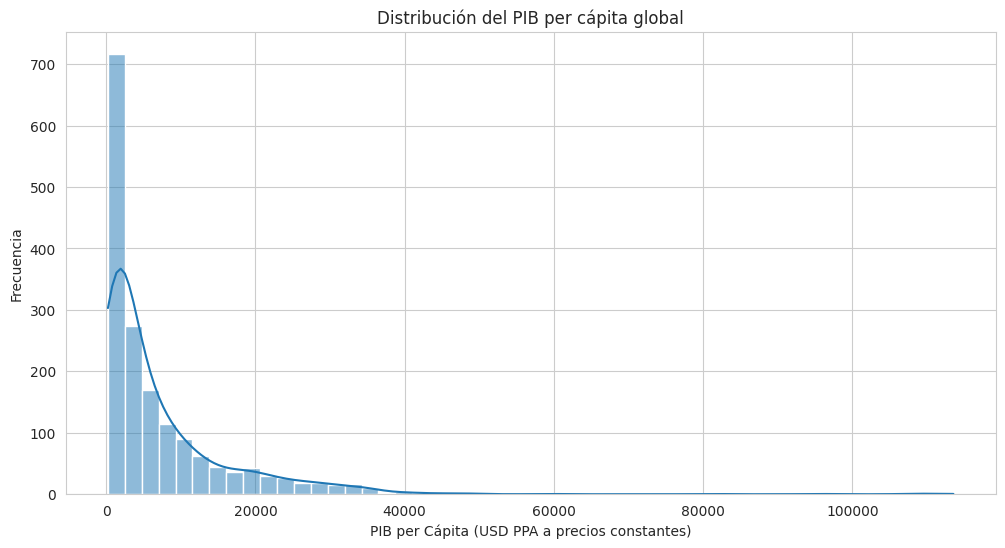

In [40]:
plt.figure(figsize=(12, 6))
sns.histplot(df['pib_per_capita'], kde=True, bins=50)
plt.title('Distribución del PIB per cápita global')
plt.xlabel('PIB per Cápita (USD PPA a precios constantes)')
plt.ylabel('Frecuencia')
plt.show()

**Ejercicio**: Interprete el gráfico.

**Interpretación:**

Distribución asimétrica positiva, sesgada a la derecha

La mayoría de países ~60% tienen PIB per cápita bajo menor a $5,000

Pocos países tienen PIB muy alto más de $30,000

La curva de densidad confirma este sesgo



#### Boxplot: Identificando la Dispersión y los Outliers

El boxplot es una de las herramientas más poderosas para un analista. Resume la distribución en 5 números (mínimo, Q1, mediana, Q3, máximo) y visualiza los outliers.

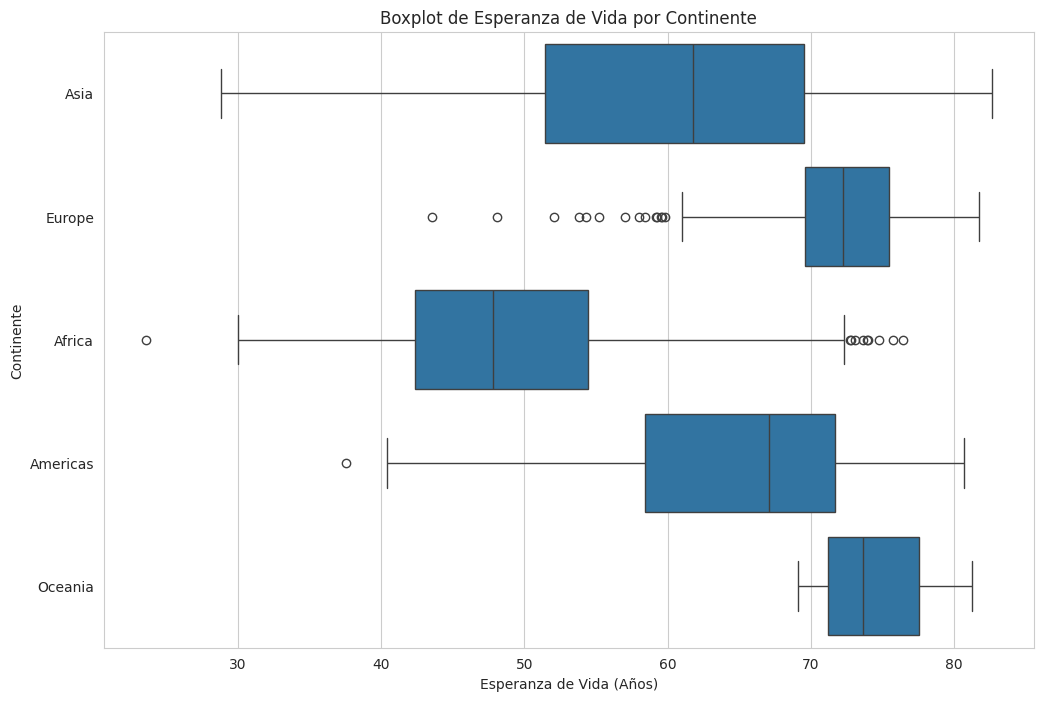

In [43]:
plt.figure(figsize=(12, 8))
sns.boxplot(y='continente', x='esperanza_vida', data=df)
plt.title('Boxplot de Esperanza de Vida por Continente')
plt.xlabel('Esperanza de Vida (Años)')
plt.ylabel('Continente')
plt.show()

**Ejercicio**: Interprete el gráfico.

**Interpretación:**

**Oceanía:** Mayor esperanza de vida mediana ~80 años, rango estrecho

**Europa:** Alta esperanza de vida mediana ~75 años, relativamente homogénea

**Américas:** Variabilidad moderada, algunos países con esperanza baja

**Asia:** Gran variabilidad, desde ~40 hasta ~80 años

**África:** Menor esperanza de vida mediana ~55 años, con outliers hacia valores muy bajos

#### Gráfico de Torta

Un gráfico de torta (o pie chart) se usa para mostrar la proporción de cada categoría sobre un total. Es visualmente atractivo, pero como veremos, puede ser más difícil de interpretar con precisión que un gráfico de barras.

In [44]:
# 1. Preparar los datos: Contar las observaciones por continente
conteo_continentes = df['continente'].value_counts()
conteo_continentes

,count
continente,
Africa,624
Asia,396
Europe,360
Americas,300
Oceania,24


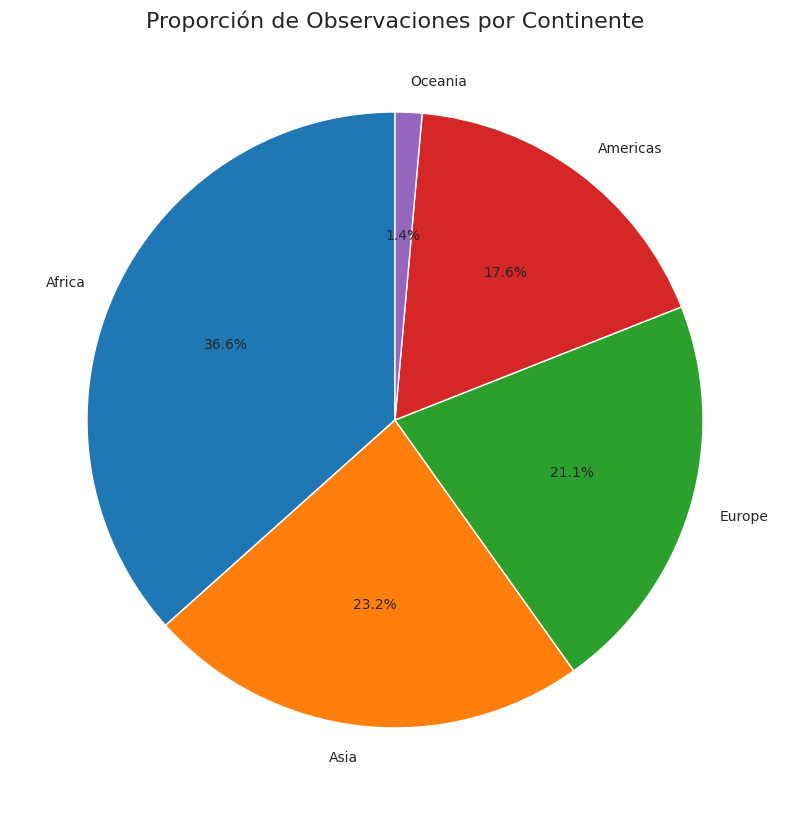

In [45]:
# 2. Crear el gráfico de torta
plt.figure(figsize=(10, 10))
plt.pie(conteo_continentes,
        labels=conteo_continentes.index,
        autopct='%1.1f%%', # Formato para mostrar porcentajes con un decimal
        startangle=90      # Inicia el primer 'trozo' en la parte superior
        )

plt.title('Proporción de Observaciones por Continente', fontsize=16)
plt.ylabel('') # Quitamos el label del eje y que matplotlib añade por defecto
plt.show()

**Ejercicio**: Interprete el gráfico.

**Interpretación:**

Africa representa la mayor proporción con ~36.6% de las observaciones

Asia le sigue con ~23.2% de los datos

Europa aporta ~21.1%

Américas contribuye con ~17.6%

Oceanía es el continente con menor representación ~1.4%

Limitación: Aunque visualmente atractivo, es difícil comparar con precisión los segmentos de tamaño similar como Europa y Américas

**Nota**

Usa un gráfico de torta solo cuando tengas pocas categorías (idealmente, menos de 5) y tu objetivo principal sea destacar la proporción de una de esas categorías con respecto al total, más que comparar las categorías entre sí.

#### Gráfico de Barras

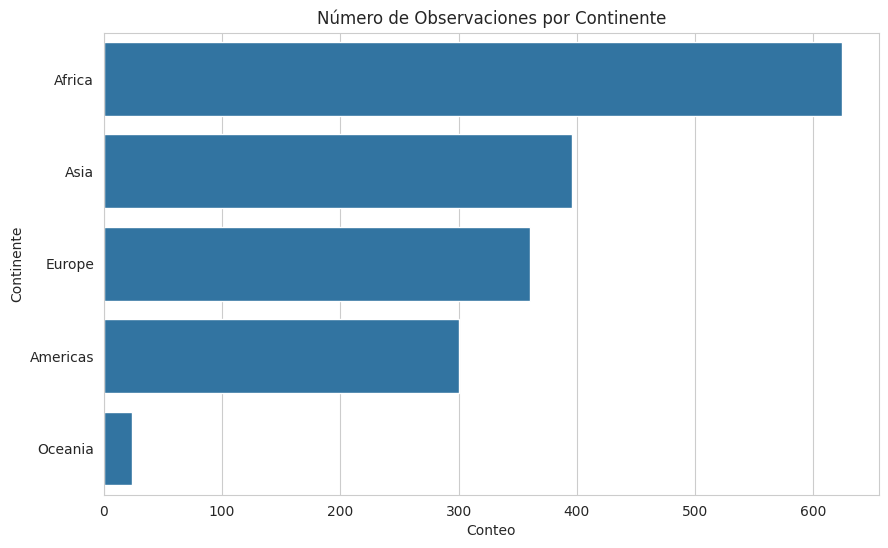

In [46]:
# Gráfico de Barras
plt.figure(figsize=(10, 6))
sns.countplot(y='continente', data=df, order = df['continente'].value_counts().index)
plt.title('Número de Observaciones por Continente')
plt.xlabel('Conteo')
plt.ylabel('Continente')
plt.show()

**Ejercicio**: Interprete el gráfico.

**Interpretación:**

Confirma los datos del gráfico de torta pero con mayor precisión visual

**Asia:** casi 400 observaciones

**África:** mas de 600 observaciones máximo

**Europa:** ~350 observaciones

**Américas:** ~300 observaciones

**Oceanía:** ~50 observaciones mínimo

**Ventaja:** Es más fácil comparar longitudes que áreas, permitiendo una interpretación más precisa

El gráfico de barras es generalmente preferible al de torta, ya que es más fácil comparar longitudes que áreas. Confirma visualmente que África y Asia dominan nuestra muestra en términos de número de observaciones (país-año).

### Visualizaciones Multivariadas (Dos o más variables)

Aquí es donde empezamos a buscar relaciones.

#### Gráfico de Dispersión (Scatter Plot)

El scatter plot es la herramienta fundamental para visualizar la relación entre dos variables numéricas.

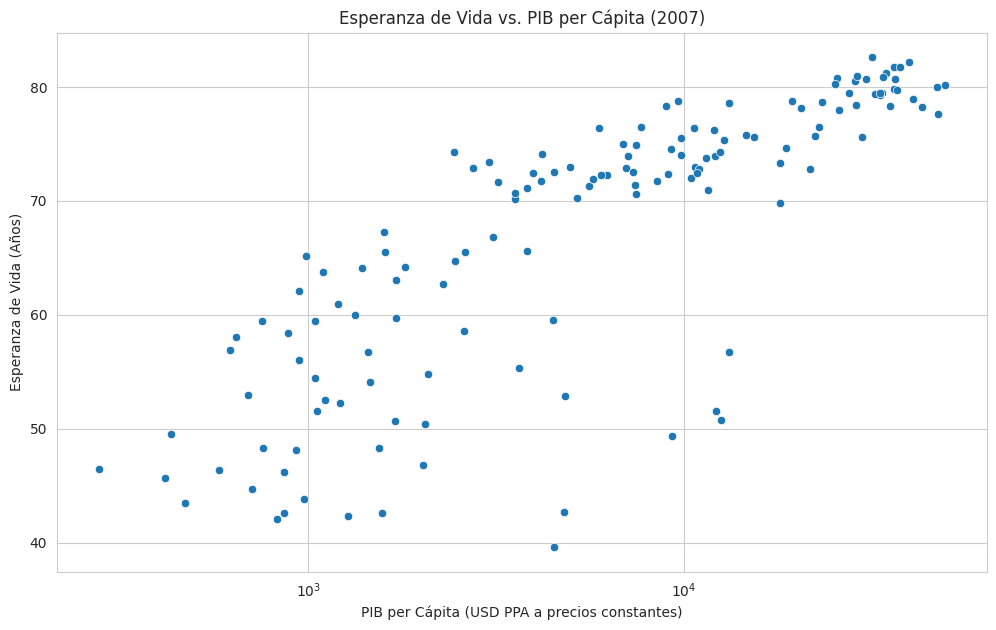

In [47]:
# Tomemos solo los datos de 2007 para una foto más clara
df_2007 = df[df['año']=='2007']

plt.figure(figsize=(12, 7))
sns.scatterplot(x='pib_per_capita', y='esperanza_vida', data=df_2007)
plt.title('Esperanza de Vida vs. PIB per Cápita (2007)')
plt.xlabel('PIB per Cápita (USD PPA a precios constantes)')
plt.ylabel('Esperanza de Vida (Años)')
plt.xscale('log') # Usamos escala logarítmica para el PIB por su gran sesgo
plt.show()

**Ejercicio**: Interprete el gráfico.

**Interpretación:**

**Relación positiva:** A mayor PIB per cápita, mayor esperanza de vida

**Relación no lineal:** El aumento es más pronunciado en países pobres efecto marginal decreciente

Países con PIB < $5,000: Gran variabilidad en esperanza de vida 40-75 años

Países con PIB > $20,000: Esperanza de vida > 75 años alta homogeneidad

**Outliers:** Algunos países con alto PIB pero esperanza de vida moderada

#### Gráfico de Burbujas: Añadiendo una Tercera Dimensión

Podemos añadir la variable poblacion al tamaño de los puntos para crear un gráfico de burbujas.

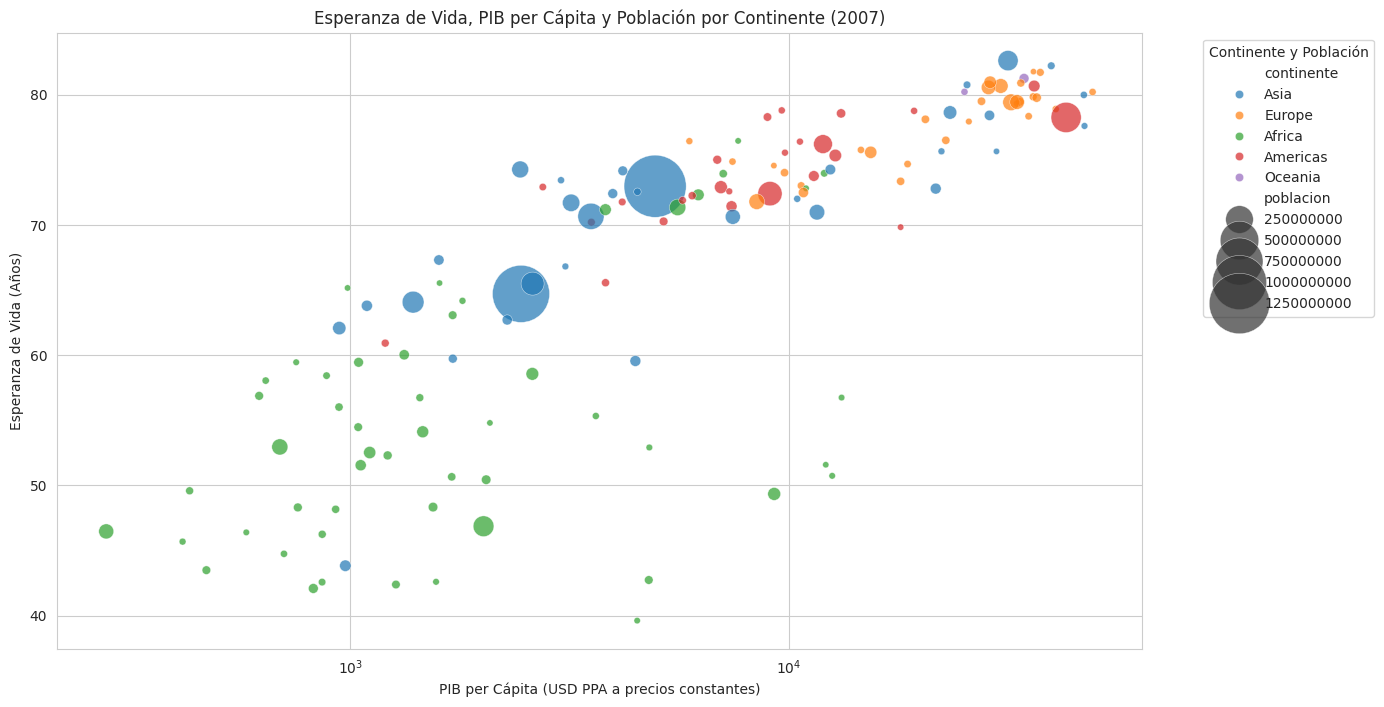

In [48]:
plt.figure(figsize=(14, 8))
sns.scatterplot(x='pib_per_capita', y='esperanza_vida', data=df_2007,
                size='poblacion', hue='continente', sizes=(20, 2000), alpha=0.7)
plt.title('Esperanza de Vida, PIB per Cápita y Población por Continente (2007)')
plt.xlabel('PIB per Cápita (USD PPA a precios constantes)')
plt.ylabel('Esperanza de Vida (Años)')
plt.xscale('log')
plt.legend(title='Continente y Población', bbox_to_anchor=(1.05, 1), loc=2)
plt.show()

**Ejercicio**: Interprete el gráfico.

**Interpretación:**

**Asia:** Burbujas grandes China, India con PIB moderado y esperanza de vida ~70-75 años

**África:** Burbujas pequeñas poblaciones menores, concentradas en PIB bajo < $5,000 y esperanza de vida baja < 60 años

**Europa:** Burbujas medianas, alta esperanza de vida > 75 años y PIB alto

**Oceanía:** Burbujas pequeñas pero con mejor posición PIB alto, esperanza alta

**África vs. Asia:** Muestra el diferente nivel de desarrollo a pesar de tener poblaciones significativas

#### Gráfico de Línea

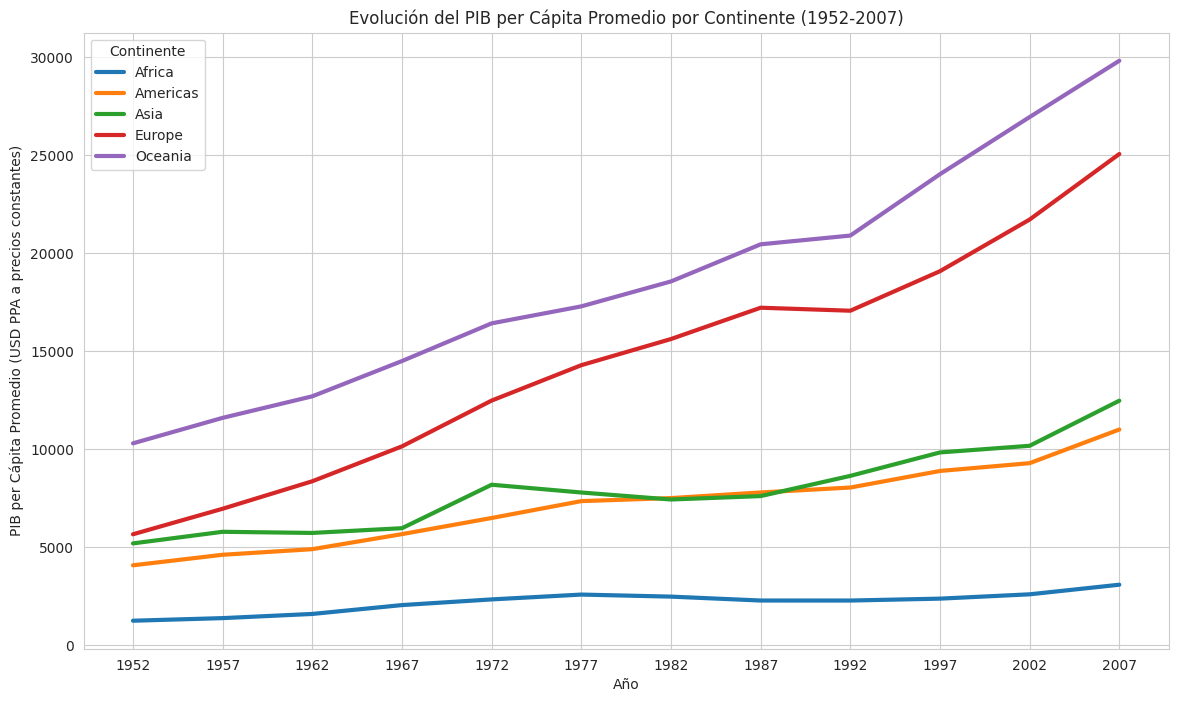

In [49]:
# Calculemos el PIB per cápita promedio por año y continente
pib_por_año_continente = df.groupby(['año', 'continente'])['pib_per_capita'].mean().reset_index()

plt.figure(figsize=(14, 8))
sns.lineplot(x='año', y='pib_per_capita', hue='continente', data=pib_por_año_continente, lw=3)
plt.title('Evolución del PIB per Cápita Promedio por Continente (1952-2007)')
plt.ylabel('PIB per Cápita Promedio (USD PPA a precios constantes)')
plt.xlabel('Año')
plt.legend(title='Continente')
plt.show()

**Ejercicio**: Interprete el gráfico.

**Interpretación:**

**Oceanía y Europa:** Posición inicial más alta 1952: ~$8,000-10,000 y crecimiento constante

**Américas:** Crecimiento sostenido, superando a Europa hacia 2007

**Asia:** Crecimiento lento hasta 1970, luego aceleración pronunciada

**África:** Crecimiento más lento, manteniéndose como el continente con menor PIB

**Brecha creciente:** La diferencia entre continentes se ha ampliado con el tiempo

#### Gráfico de Barras Apiladas

Mientras que un gráfico de líneas es bueno para comparar las tendencias de cada continente por separado, un gráfico de barras apiladas nos permite responder dos preguntas a la vez:

- ¿Cómo ha crecido la población total de nuestra muestra a lo largo de los años? (Altura total de la barra)

- ¿Cómo ha cambiado la participación porcentual de cada continente en esa población total? (Tamaño relativo de cada color dentro de la barra)

Para crearlo, primero necesitamos reorganizar (pivotar) nuestros datos para que los años sean el índice, los continentes sean las columnas y los valores sean la suma de la población.

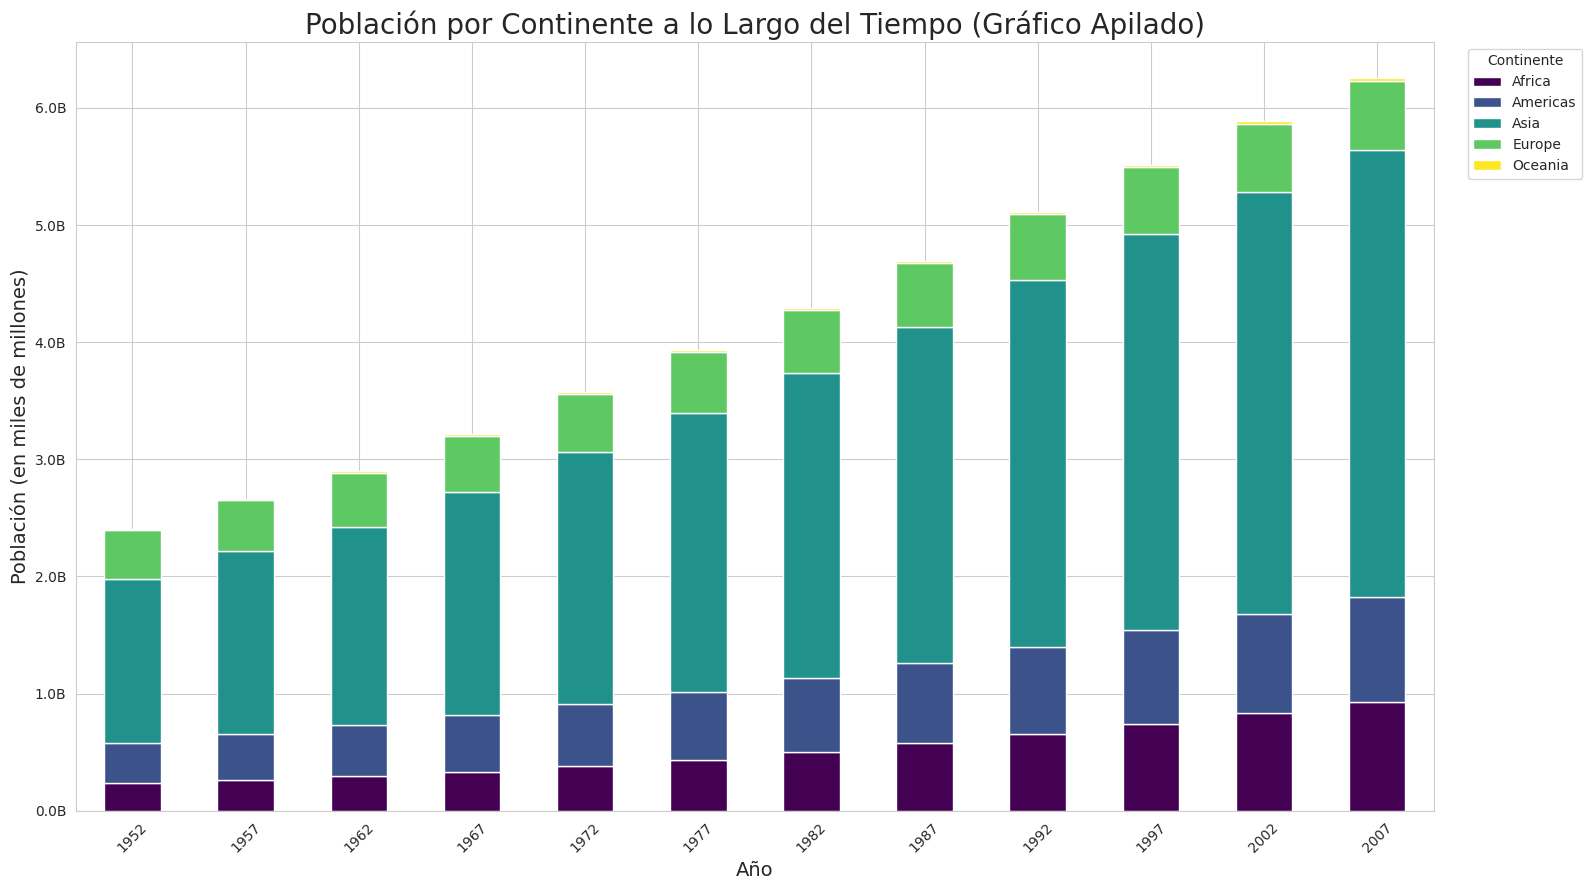

In [50]:
# 1. Preparar los datos: Crear una tabla pivote
# Agrupamos por año y continente, sumando la población.
# Luego, usamos .unstack() para convertir los continentes en columnas.
poblacion_continentes = df.groupby(['año', 'continente'])['poblacion'].sum().unstack()

# 2. Crear el gráfico de barras apiladas
ax = poblacion_continentes.plot(kind='bar', stacked=True, figsize=(16, 9),
                                 colormap='viridis')

# 3. Mejorar la legibilidad del gráfico
plt.title('Población por Continente a lo Largo del Tiempo (Gráfico Apilado)', fontsize=20)
plt.xlabel('Año', fontsize=14)
plt.ylabel('Población (en miles de millones)', fontsize=14)
plt.xticks(rotation=45)
plt.legend(title='Continente', bbox_to_anchor=(1.02, 1), loc='upper left')

# Formatear el eje Y para que muestre los números en miles de millones
# Esto hace que el gráfico sea mucho más fácil de leer.
formatter = lambda x, pos: f'{x/1e9:.1f}B'
ax.yaxis.set_major_formatter(formatter)

plt.tight_layout()
plt.show()

**Ejercicio**: Interprete el gráfico.

**Interpretación:**

**Población total mundial:** Crecimiento exponencial de ~2.5B 1952 a ~6.5B 2007

**Asia:** Siempre el mayor contribuyente, mantiene ~60% de la población total

**África:** Segundo mayor, con participación creciente

**Europa:** Participación relativa decreciente de ~20% a ~12%

**Oceanía:** Participación marginal menos del 1%

**Implicación:** El crecimiento poblacional se concentra en Asia y África



## Correlación

Los gráficos de dispersión sugieren relaciones. La correlación las cuantifica numéricamente.

- Correlación > 0: Relación positiva (cuando X sube, Y tiende a subir).

- Correlación < 0: Relación negativa (cuando X sube, Y tiende a bajar).

- Correlación ≈ 0: No hay relación lineal.

Un **heatmap** es una forma excelente de visualizar la matriz de correlación, usando colores para representar los valores.

In [51]:
# Seleccionamos solo las columnas numéricas para la correlación
df_numeric = df[['esperanza_vida', 'poblacion', 'pib_per_capita']]
correlation_matrix = df_numeric.corr()
correlation_matrix

,esperanza_vida,poblacion,pib_per_capita
esperanza_vida,1.00,0.06,0.58
poblacion,0.06,1.00,-0.03
pib_per_capita,0.58,-0.03,1.00


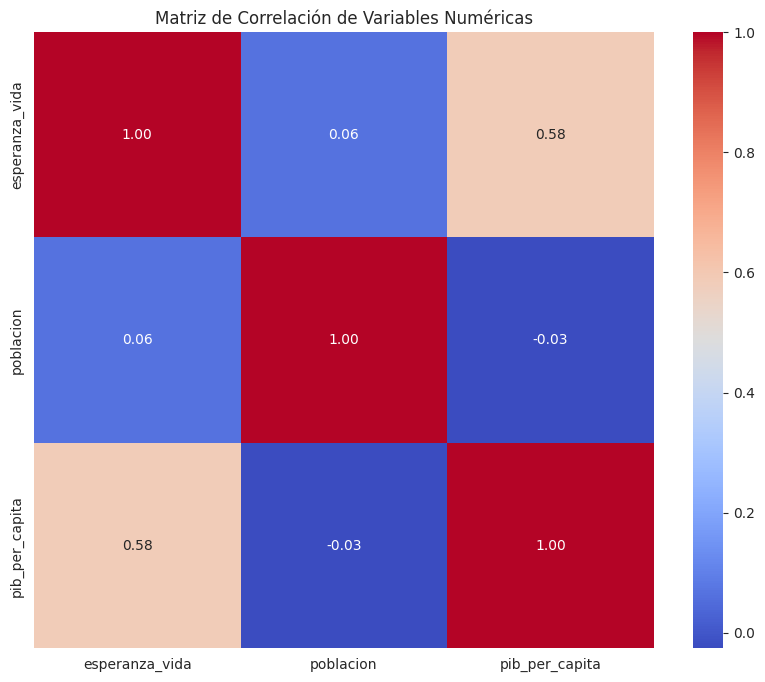

In [52]:
plt.figure(figsize=(10, 8))
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', fmt=".2f")
plt.title('Matriz de Correlación de Variables Numéricas')
plt.show()

**Ejercicio**: Interprete el gráfico.

**Interpretación:**

**PIB per cápita vs. Esperanza de vida:** 0.58 → Correlación positiva moderada

**PIB per cápita vs. Población:** 0.05 → Prácticamente no hay correlación

**Población vs. Esperanza de vida:** 0.06 → Correlación muy débil cercana a cero

⚠️ Advertencia clave: **¡Correlación no implica causalidad!** El hecho de que dos variables se muevan juntas no significa que una cause la otra. Podría haber una tercera variable oculta (variable omitida) o la causalidad podría ir en la dirección opuesta.

**Ejercicio de discusión**

Hemos visto una correlación de 0.58 entre PIB per cápita y esperanza de vida. Pero, ¿es una prueba de que 'el dinero compra la salud'? Piensen por un minuto en al menos una tercera variable (una variable omitida) que podría estar causando que tanto el PIB como la esperanza de vida se muevan juntas.

## Gráficos Avanzados con Seaborn

Seaborn ofrece herramientas de alto nivel para explorar relaciones complejas con poco código.

### Pairplot: Todas las Relaciones de un Vistazo

El pairplot crea una matriz de gráficos: histogramas en la diagonal (para ver la distribución de cada variable) y scatter plots en el resto (para ver la relación entre cada par de variables). Es una forma increíblemente eficiente de obtener una visión general.

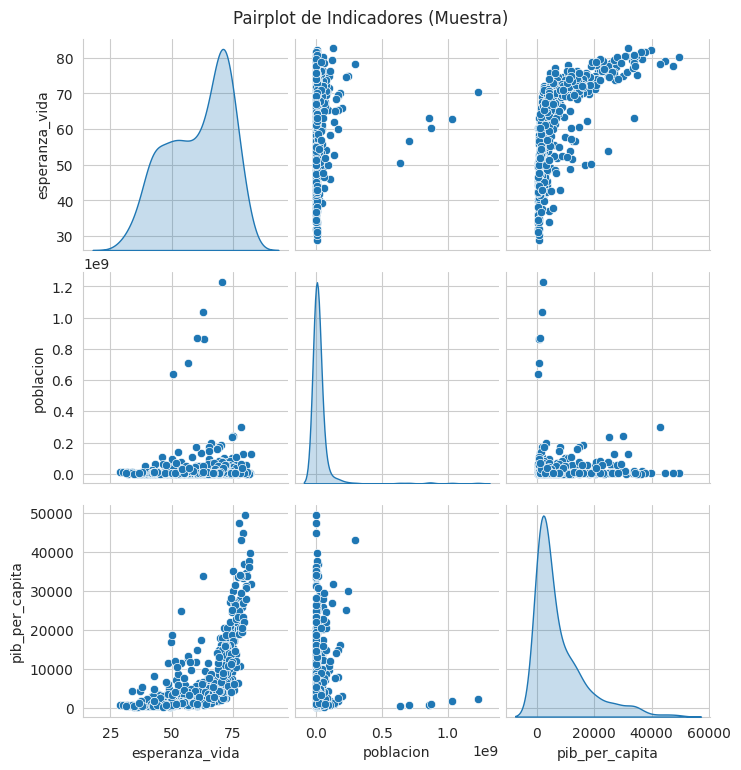

In [53]:
# Usamos una muestra de los datos para que el gráfico se genere más rápido
df_sample = df.sample(500)

sns.pairplot(df_sample, diag_kind='kde')
plt.suptitle('Pairplot de Indicadores (Muestra)', y=1.02)
plt.show()

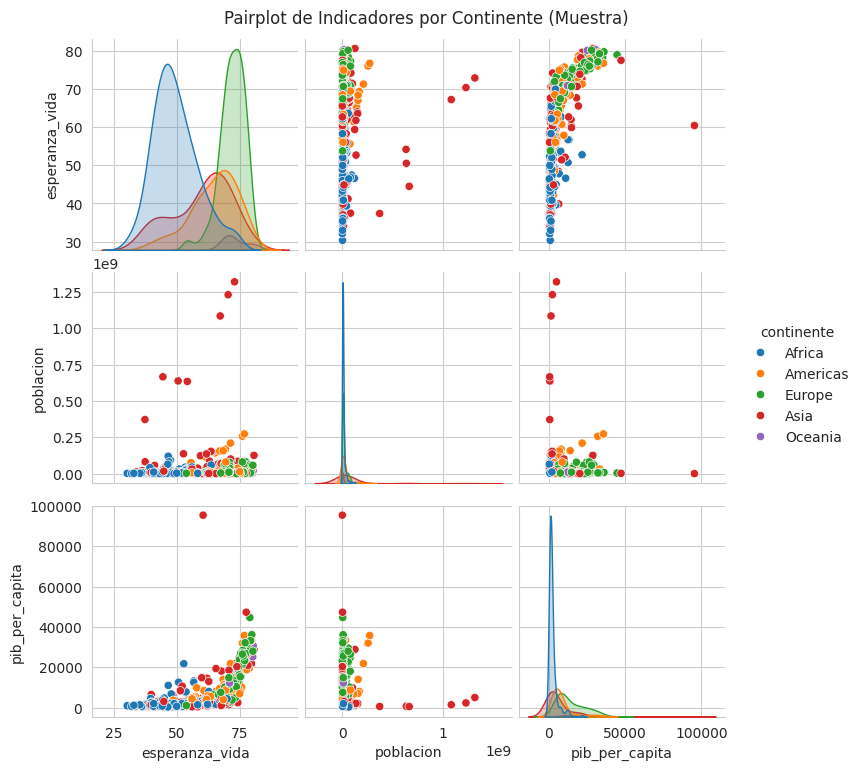

In [54]:
# Usamos una muestra de los datos para que el gráfico se genere más rápido
df_sample = df.sample(500)

sns.pairplot(df_sample, hue='continente', diag_kind='kde')
plt.suptitle('Pairplot de Indicadores por Continente (Muestra)', y=1.02)
plt.show()

Este único comando genera una gran cantidad of información. Podemos ver todas las relaciones bivariadas simultáneamente, segmentadas por color según el continente. Rápidamente podemos confirmar visualmente las correlaciones que vimos en el heatmap y las distribuciones de los histogramas, pero ahora con una capa adicional de detalle por continente.

### Violinplot

Combina un boxplot con un gráfico de densidad. Es útil para ver no solo el resumen estadístico sino también la forma completa de la distribución.

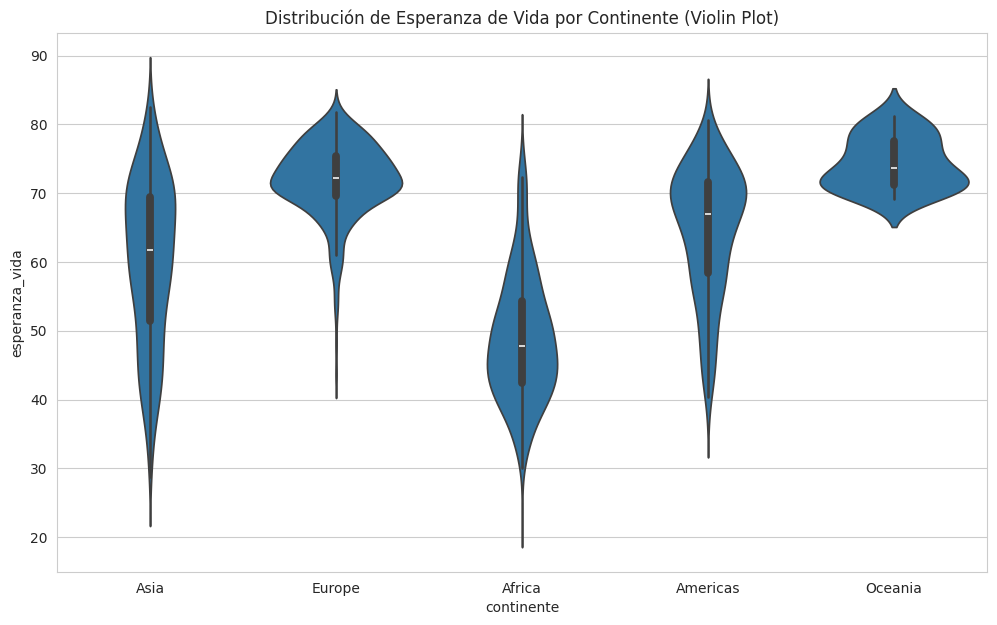

In [55]:
plt.figure(figsize=(12, 7))
sns.violinplot(x='continente', y='esperanza_vida', data=df)
plt.title('Distribución de Esperanza de Vida por Continente (Violin Plot)')
plt.show()

### Joint Plot

Muestra un scatter plot de dos variables y añade los histogramas o gráficos de densidad de cada variable en los márgenes.

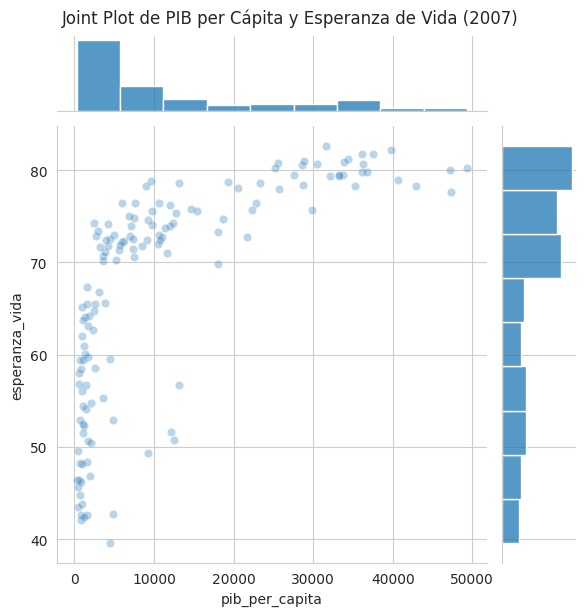

In [56]:
sns.jointplot(x='pib_per_capita', y='esperanza_vida', data=df_2007, alpha=0.3,marker='o')
plt.suptitle('Joint Plot de PIB per Cápita y Esperanza de Vida (2007)', y=1.02)
plt.show()

**Conclusión de este Análisis Exploratorio**

A través de este análisis estadístico, hemos extraído valiosos insights económicos sin correr un solo modelo formal:

- **Desigualdad Global:** Existe una enorme disparidad en el PIB per cápita y la esperanza de vida entre países y continentes.

- **Rendimientos Decrecientes de la Riqueza en la Salud:** La relación entre ingreso y esperanza de vida es positiva pero no lineal, sugiriendo que las políticas enfocadas en sacar a los países de la pobreza extrema tienen un impacto desproporcionadamente alto en la salud.

- **Dinámicas Continentales:** Los continentes muestran trayectorias de desarrollo muy diferentes, con una notable divergencia después de 1950 y un reciente y rápido crecimiento en Asia.

- **Calidad de los Datos:** Nuestro dataset está completo, pero en un caso real, esta fase habría sido crucial para detectar y planificar cómo manejar valores nulos o outliers problemáticos.

Ahora, con una comprensión intuitiva y profunda de la estructura y las relaciones en nuestros datos, estamos mucho mejor preparados para la siguiente fase: el machine learning.